In [44]:
from utility.plot_spectrum import plot_spectrum
from utility.adjust_redshift import adjust_redshift

from processing.remove_spikes import remove_spikes
from processing.fit_continuum import fit_continuum
from processing.quality_cuts import quality_cuts
from processing.get_absorption_intervals import get_absorption_intervals
from processing.fit_gaussians import fit_single_gaussian, fit_two_gaussians, ftest_which_gaussian
from processing.measure_line import measure_line
from processing.parameters import CIV_CONTINUUM_WINDOWS, CIV_FIT_WINDOW, NV_LYA_CONTINUUM_WINDOWS, CIV_AIR, LYA_AIR, NV_AIR

import pandas as pd
import numpy as np

relevant_erq_data_path = "data/relevant_erq_data.json"

In [2]:
data = pd.read_json(relevant_erq_data_path)

In [42]:
idx = 0

lam = np.array(data["wavelength"][idx])
flux = np.array(data["flux"][idx])
ivar = np.array(data["ivar"][idx])
z = data["redshift"][idx]


## ADJUST REDSHIFT
lam, flux, ivar = adjust_redshift(z, lam, flux, ivar=ivar)


## EXTRACT VALID PIXELS & REMOVE OUTLIERS

# mask bad pixels, i.e. pixels where flux is zero, ivar is zero or infinity
valid_pixel_mask = np.where(((lam > 1150) & (lam < 1810)) & (ivar > 0) & np.isfinite(ivar) & (flux != 0), True, False)

# apply mask
lam = lam[valid_pixel_mask]
flux = flux[valid_pixel_mask]
ivar = ivar[valid_pixel_mask]

# remove spikes
flux_clean, _ = remove_spikes(lam,flux,ivar=ivar)


## FIT COONTINUUM BELOW CIV
result, continuum_civ, _ = fit_continuum(lam, flux_clean, ivar=ivar, windows=CIV_CONTINUUM_WINDOWS, lambda_ref=1700.0)


## QUALITY CUTS (based on CIV region)

# TODO: fix all this, like i think it doesnt do shit currently and you need to get the values fixed
rejected, reason, flags = quality_cuts(lam, flux_clean, continuum_civ, result, max_slope=10.0)

if rejected:
    print(f'Rejected because: {reason}')
    
else:

    ## GET CIV ABSORPTION MASK
    _, civ_absorption_mask = get_absorption_intervals(lam,flux_clean,ivar,continuum_civ)  # first is intervals for plotting


    ## FIT CIV LINE

    # subtract CIV flux
    flux_sub_civ = flux_clean - continuum_civ if not rejected else None

    # fit single gaussian, use result as parameter guesses for two gaussian fit
    result1_civ, profile1_civ = fit_single_gaussian(lam, flux_sub_civ, ivar=ivar, mask=civ_absorption_mask, window=CIV_FIT_WINDOW)
    result2_civ, profile2_civ = fit_two_gaussians(lam, flux_sub_civ, ivar=ivar, mask=civ_absorption_mask, single_result=result1_civ, window=CIV_FIT_WINDOW)

    # F-test which fit is better, assign to general variable
    accept_two_civ, p_val_civ = ftest_which_gaussian(result1_civ, result2_civ)
    profile_civ = profile2_civ if accept_two_civ else profile1_civ


    ## CONTINUUM BELOW NV AND LYA
    _, continuum_nv_lya, _ = fit_continuum(lam, flux_clean, ivar=ivar, windows=NV_LYA_CONTINUUM_WINDOWS, lambda_ref=1290.0)  # fit continuum
    flux_sub_nv_lya = flux_clean - continuum_nv_lya  # subtract continuum

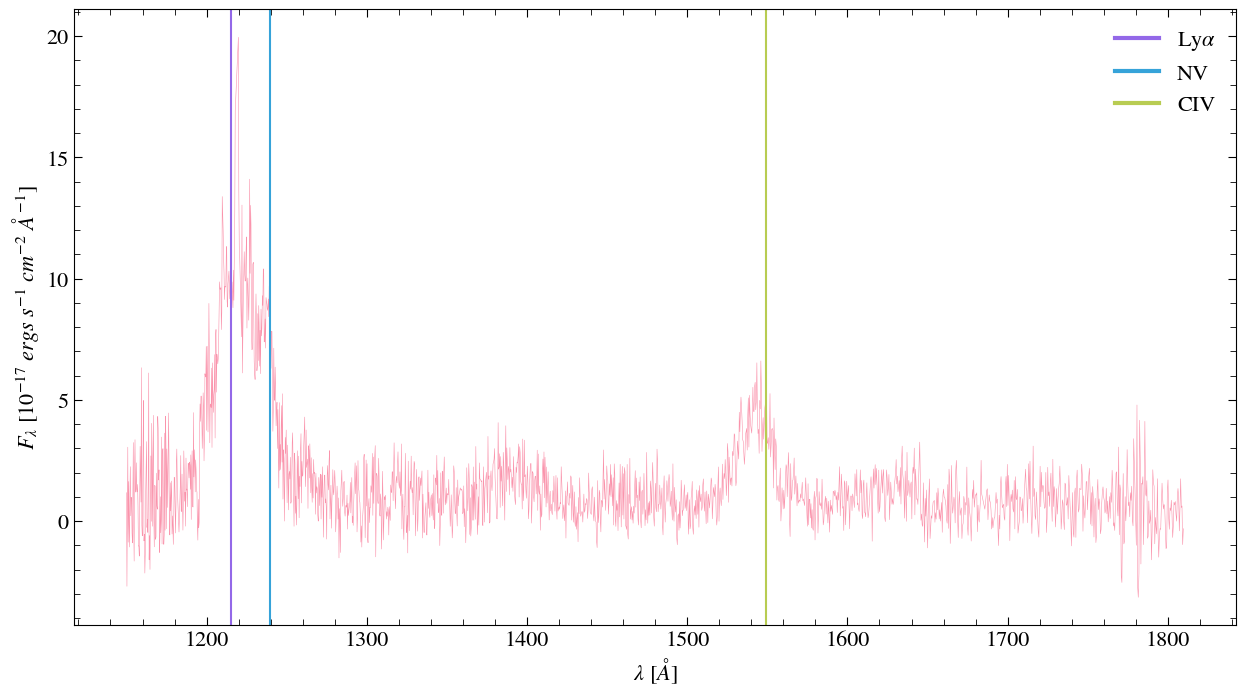

In [45]:
plot_spectrum(lam,flux_clean,line_lambda=[LYA_AIR,NV_AIR,CIV_AIR],line_label=[r"Ly$\alpha$","NV","CIV"])

In [15]:
civ_absorption_mask

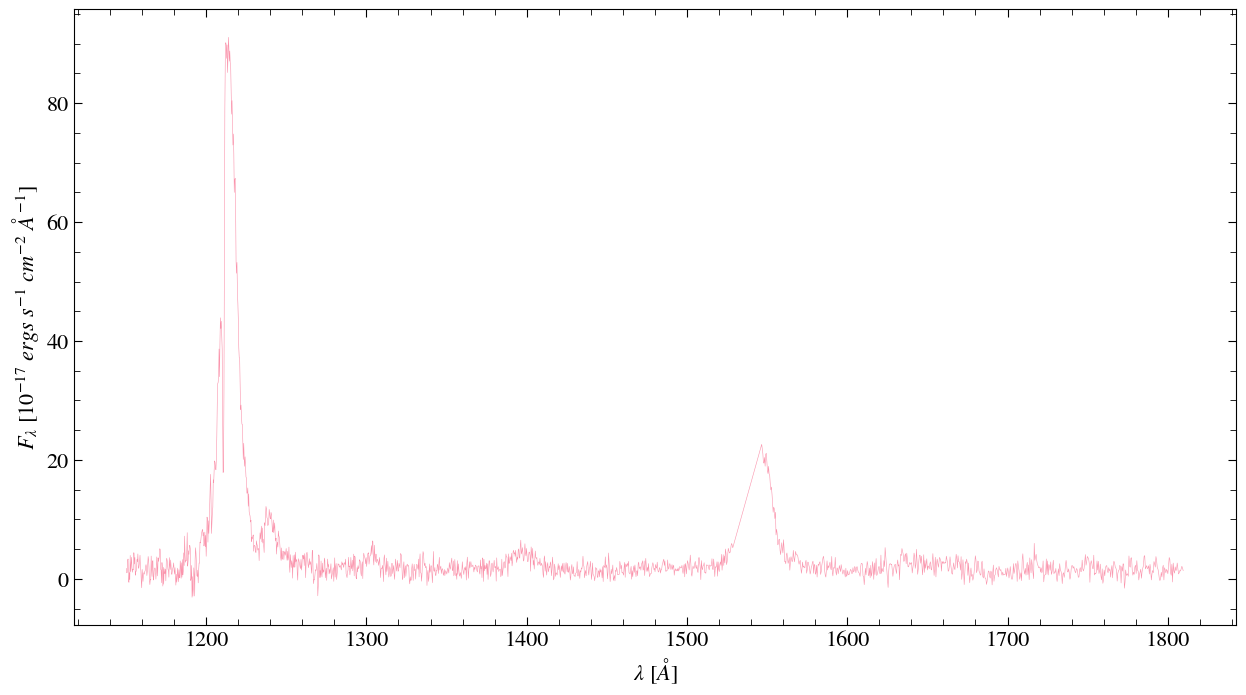

In [35]:
plot_spectrum(lam[~civ_absorption_mask],flux_clean[~civ_absorption_mask])